In [13]:
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN
from scipy.interpolate import interp1d

pd.set_option('display.max_columns', None)


## 1. Importing Las File

In [14]:
las=lasio.read("University_of_Utah_Forge_56_32_ThrubitDipole_Aniso_analysis_result_3452-9050ft_LAS.las")
df_wireline=las.df()
df_wireline['MD']=df_wireline.index
df_wireline.reset_index(drop=True, inplace=True)

In [15]:
df_wireline.shape

(11197, 28)

In [16]:
df_wireline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11197 entries, 0 to 11196
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AZIM              11197 non-null  float64
 1   BS_RM             11197 non-null  float64
 2   C1_24             11197 non-null  float64
 3   DEVI              11197 non-null  float64
 4   DTCO_MPS_R        11166 non-null  float64
 5   DTSH_FAST         11176 non-null  float64
 6   DTSH_SLOW         11176 non-null  float64
 7   FSA_ERRMINUS      11178 non-null  float64
 8   FSA_ERRPLUS       11178 non-null  float64
 9   FSA_NAZ_IN        1315 non-null   float64
 10  FSA_TOH           11178 non-null  float64
 11  GR_TMG            11197 non-null  float64
 12  MAXXENE_OVERALL   11178 non-null  float64
 13  MINXENE_OVERALL   11178 non-null  float64
 14  PR_FAST           11166 non-null  float64
 15  RB                11173 non-null  float64
 16  SENSOR_AZIM_QCI   11180 non-null  float6

In [17]:
df_wireline = df_wireline.drop(columns=['FSA_NAZ_IN'])

In [18]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_wireline.dropna())

In [19]:
X_scaled.shape

(11154, 27)

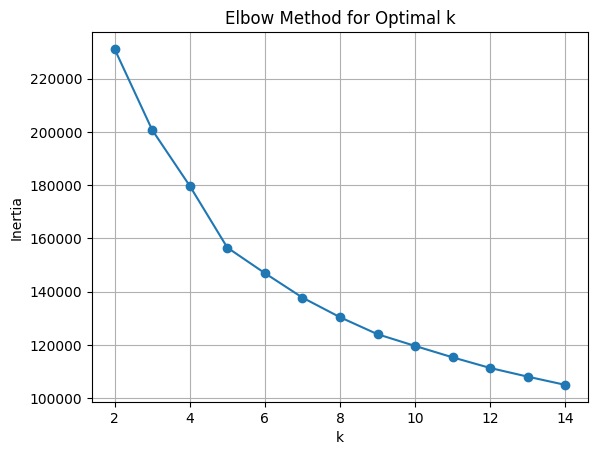

CPU times: user 874 ms, sys: 359 ms, total: 1.23 s
Wall time: 179 ms


In [20]:
%%time
inertias = []
k_values = range(2, 15)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)  # use same scaler from previous step
    inertias.append(model.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

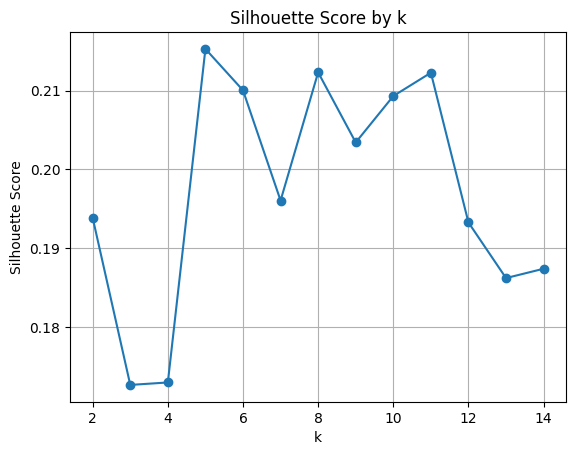

In [21]:
from sklearn.metrics import silhouette_score

scores = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(k_values, scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.grid(True)
plt.show()


In [22]:
print("k_values:", list(k_values))
print("inertias:",inertias)
print("silhouette score:",scores)

k_values: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
inertias: [231198.50390818084, 200761.74985654635, 179752.1342549466, 156539.20397705905, 146926.15215653728, 137740.13007217424, 130369.9395345007, 123973.73242959967, 119568.18534363122, 115276.21647481117, 111280.61080069945, 108020.66918070544, 104928.59302040031]
silhouette score: [np.float64(0.19385402866075876), np.float64(0.17268398750859967), np.float64(0.1729960558132066), np.float64(0.21527416566574942), np.float64(0.21002590727044598), np.float64(0.19605644019734034), np.float64(0.21230013335864809), np.float64(0.20341954033538936), np.float64(0.20930198543424006), np.float64(0.2122577356347059), np.float64(0.19327310226136002), np.float64(0.1862275887211807), np.float64(0.18741065937595558)]


In [96]:
def perform_kmeans_clustering(df, features, n_clusters=8):
    """
    Perform KMeans clustering on selected features of a DataFrame.

    Parameters:
    - df: pandas DataFrame containing the data
    - features: list of column names to use for clustering
    - n_clusters: number of clusters to form

    Returns:
    - df_clustered: DataFrame with cluster labels added
    - model: fitted KMeans model
    - scaler: fitted StandardScaler
    """
    # Step 1: Drop rows with NaNs in selected features
    df_clustered = df[['MD'] + features].dropna().copy()

    # Step 2: Standardize the selected features
    X = df_clustered[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 3: Apply KMeans clustering
    model = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = model.fit_predict(X_scaled)

    # Step 4: Attach cluster labels to DataFrame
    df_clustered['Cluster'] = cluster_labels

    return df_clustered, model, scaler

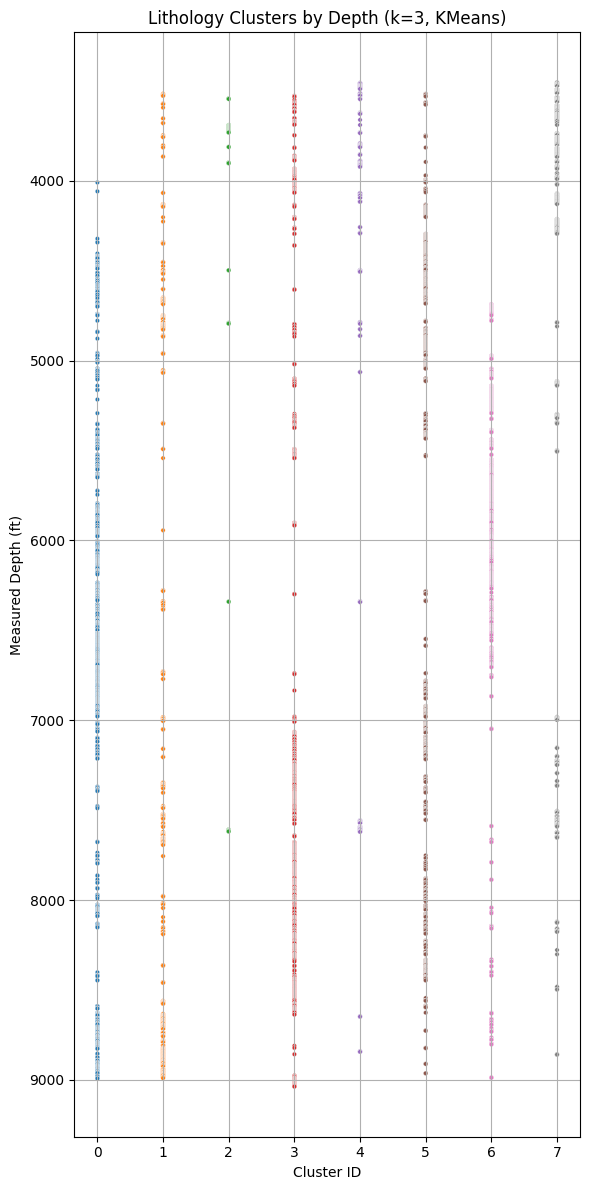

In [98]:
df_kmeans_3, kmeans_model_3, scaler_3 = perform_kmeans_clustering(
    df=df_wireline,
    features=['GR_TMG', 'DTCO_MPS_R', 'TNPH'],
    n_clusters=8
)

# Plot clusters over depth
plt.figure(figsize=(6, 12))
sns.scatterplot(
    data=df_kmeans_3,
    x='Cluster',
    y='MD',
    hue='Cluster',
    palette='tab10',
    s=10,
    legend=False
)
plt.gca().invert_yaxis()
plt.title("Lithology Clusters by Depth (k=3, KMeans)")
plt.xlabel("Cluster ID")
plt.ylabel("Measured Depth (ft)")
plt.grid(True)
plt.tight_layout()
plt.show()


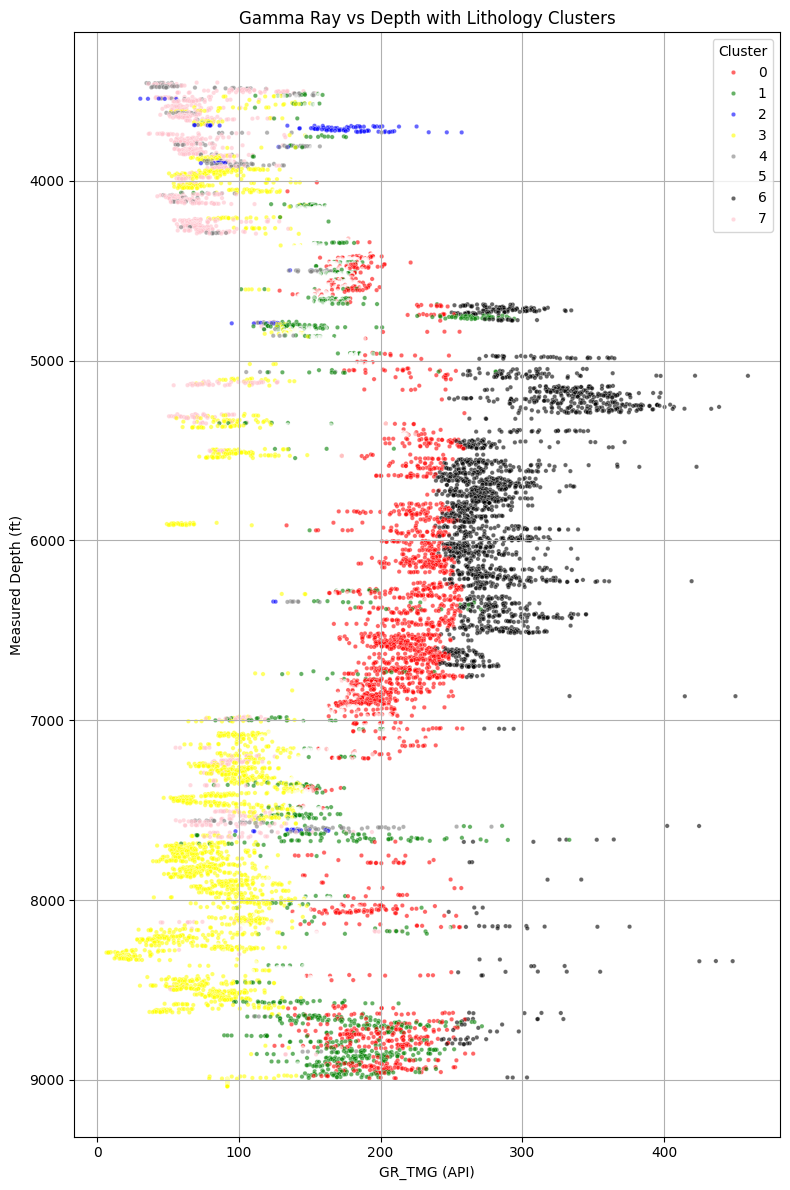

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'MD', 'GR_TMG', and 'Cluster' columns exist in df_kmeans_3
plt.figure(figsize=(8, 12))

# Set a color palette for the clusters
palette = {0: 'red', 1: 'green', 2: 'blue', 3:'yellow', 4:'grey', 5:"white",6:"black", 7:"pink"}

# Plot GR_TMG vs Depth, colored by cluster
sns.scatterplot(
    data=df_kmeans_3,
    x='GR_TMG',
    y='MD',
    hue='Cluster',
    palette=palette,
    s=10,  # point size
    alpha=0.6
)

plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel("GR_TMG (API)")
plt.ylabel("Measured Depth (ft)")
plt.title("Gamma Ray vs Depth with Lithology Clusters")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


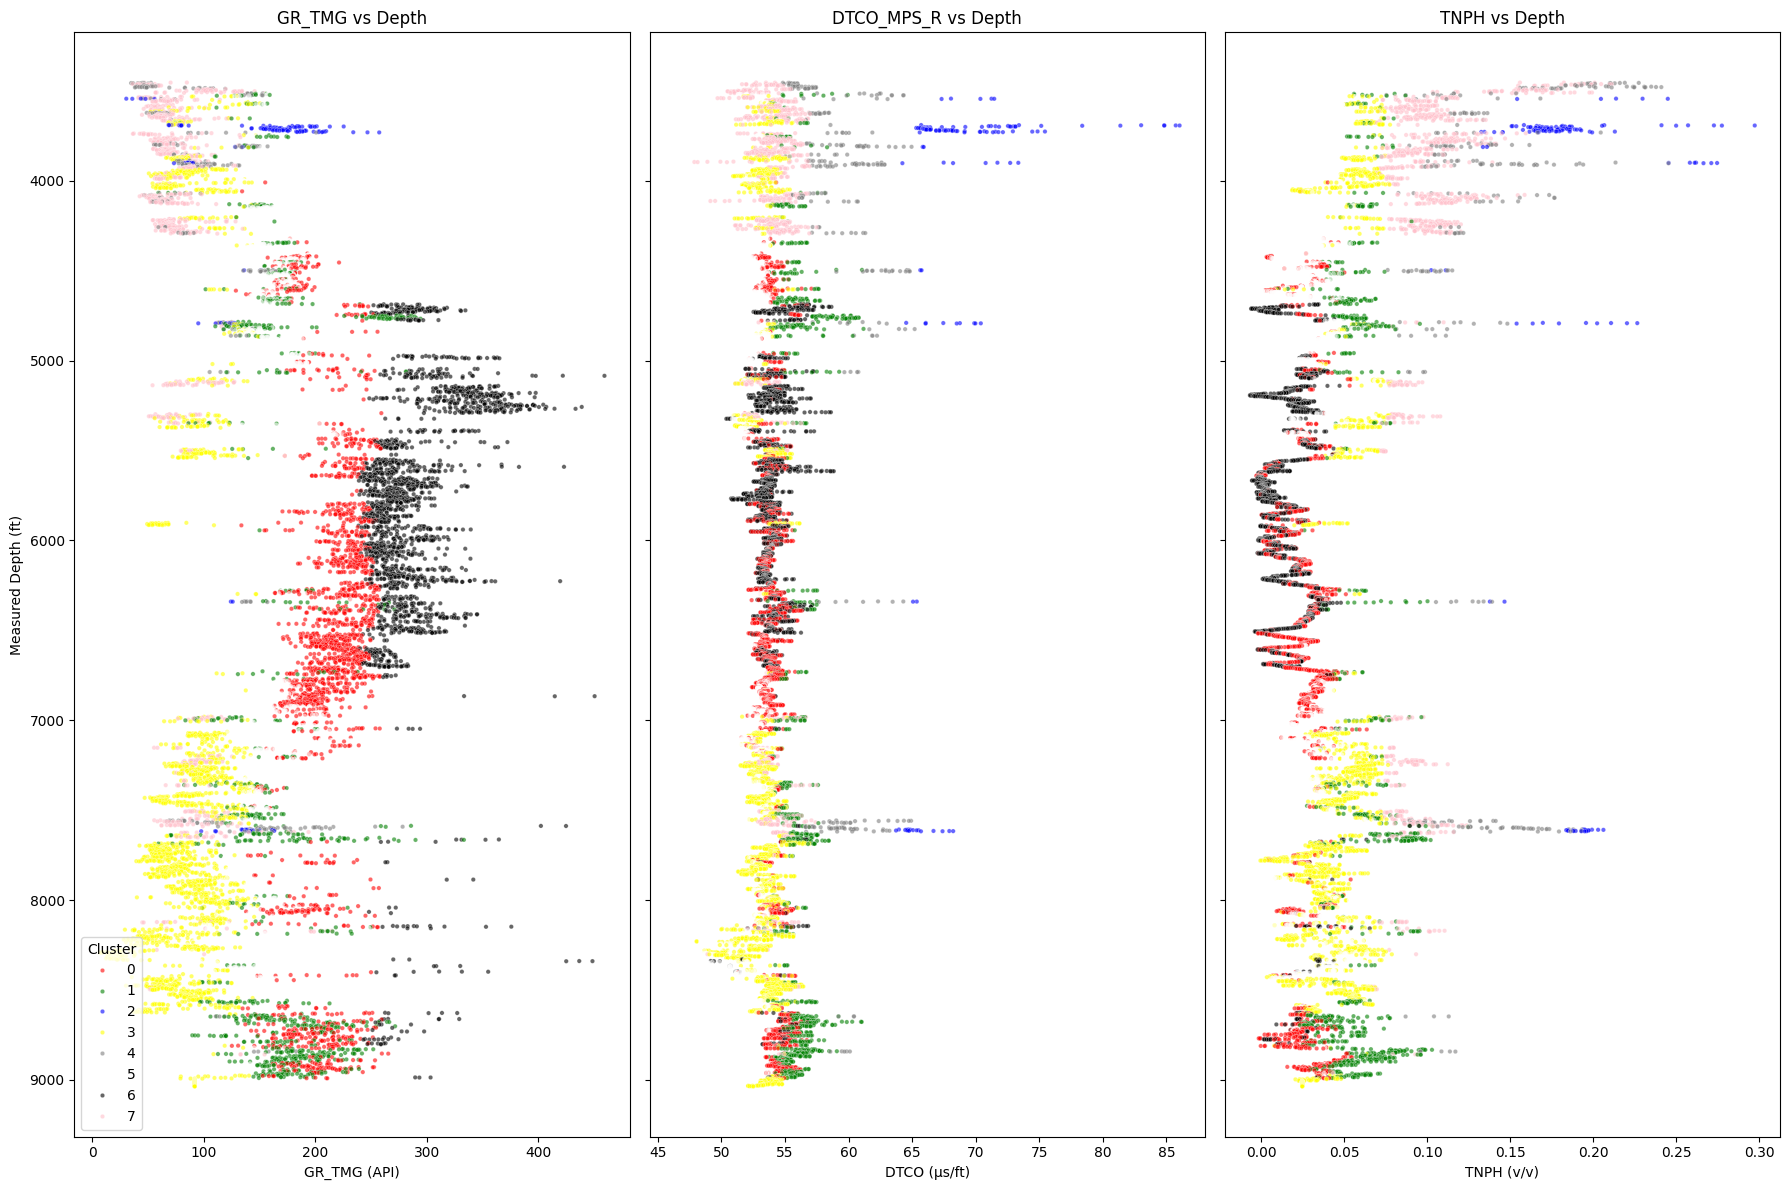

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample structure creation for demonstration (since df_kmeans_3 not accessible directly)
# You would replace this with your actual df_kmeans_3 DataFrame
# df_kmeans_3 = pd.read_csv("your_data.csv")  # Example of loading actual data if needed

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 12), sharey=True)

# Define color palette
palette = {0: 'red', 1: 'green', 2: 'blue', 3:'yellow', 4:'grey', 5:"white",6:"black", 7:"pink"}


# GR_TMG vs Depth
sns.scatterplot(
    data=df_kmeans_3,
    x='GR_TMG',
    y='MD',
    hue='Cluster',
    palette=palette,
    s=10,
    alpha=0.6,
    ax=axes[0]
)
axes[0].invert_yaxis()
axes[0].set_xlabel("GR_TMG (API)")
axes[0].set_ylabel("Measured Depth (ft)")
axes[0].set_title("GR_TMG vs Depth")

# DTCO_MPS_R vs Depth
sns.scatterplot(
    data=df_kmeans_3,
    x='DTCO_MPS_R',
    y='MD',
    hue='Cluster',
    palette=palette,
    s=10,
    alpha=0.6,
    ax=axes[1]
)
axes[1].invert_yaxis()
axes[1].set_xlabel("DTCO (μs/ft)")
axes[1].set_title("DTCO_MPS_R vs Depth")

# TNPH vs Depth
sns.scatterplot(
    data=df_kmeans_3,
    x='TNPH',
    y='MD',
    hue='Cluster',
    palette=palette,
    s=10,
    alpha=0.6,
    ax=axes[2]
)
axes[2].invert_yaxis()
axes[2].set_xlabel("TNPH (v/v)")
axes[2].set_title("TNPH vs Depth")

# Adjust layout and remove duplicate legends
axes[1].get_legend().remove()
axes[2].get_legend().remove()
axes[0].legend(title="Cluster", loc="lower left")

plt.tight_layout()
plt.show()


<Axes: >

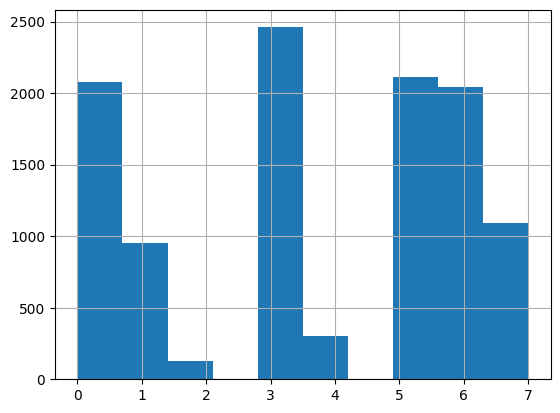

In [105]:
df_kmeans_3['Cluster'].hist()

In [106]:
print(df_kmeans_3.groupby('Cluster')[['GR_TMG', 'DTCO_MPS_R', 'TNPH']].describe().round(2))

         GR_TMG                                                         \
          count    mean    std     min     25%     50%     75%     max   
Cluster                                                                  
0        2076.0  210.84  26.55  125.16  191.19  213.33  232.76  265.33   
1         952.0  171.01  42.24   59.28  144.82  166.07  193.11  333.16   
2         128.0  150.47  44.19   30.46  127.78  157.43  181.32  257.23   
3        2460.0   86.14  27.09    6.60   67.38   87.64  104.48  150.22   
4         300.0  106.67  44.58   34.82   69.18  101.43  142.08  278.24   
5        2111.0  163.91  25.40   59.58  147.89  164.48  179.04  319.06   
6        2046.0  288.75  34.96  238.02  263.25  278.71  305.55  459.18   
7        1093.0   77.80  23.06   36.17   61.95   71.89   89.14  214.76   

        DTCO_MPS_R                                                    TNPH  \
             count   mean   std    min    25%    50%    75%    max   count   
Cluster                      

In [107]:
cluster_to_litho = {
    0: 'Shale / Altered Zone',
    1: 'Granodiorite',
    2: 'Alluvium / Transition'
}

df_kmeans_3['Lithology_Label']=df_kmeans_3['Cluster'].map(cluster_to_litho)

In [108]:
cluster_to_litho = {
    0: 'Granodiorite',
    1: 'Alluvium',
    2: 'Transition Zone'
}

df_kmeans_3['Lithology_Label'] = df_kmeans_3['Cluster'].map(cluster_to_litho)


<Axes: >

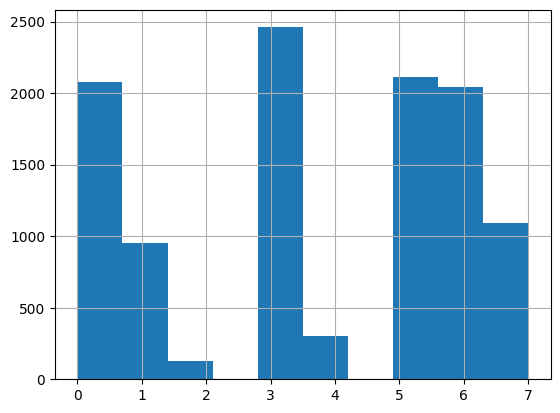

In [109]:
df_kmeans_3['Cluster'].hist()

In [110]:
# Pick the same features you used in the boxplots
features = ['GR_TMG', 'DTCO_MPS_R', 'TNPH']

# Compute summary statistics per cluster
summary_stats = df_kmeans_3.groupby('Cluster')[features].describe().round(2)

# View only means
cluster_means = df_kmeans_3.groupby('Cluster')[features].mean().round(2)
print("Cluster Means:\n", cluster_means)

# (Optional) View all summary stats
summary_stats


Cluster Means:
          GR_TMG  DTCO_MPS_R  TNPH
Cluster                          
0        210.84       53.92  0.02
1        171.01       55.96  0.06
2        150.47       68.88  0.19
3         86.14       53.35  0.05
4        106.67       59.38  0.14
5        163.91       52.20  0.03
6        288.75       53.94  0.02
7         77.80       53.99  0.10


GR_TMG                                                         \
          count    mean    std     min     25%     50%     75%     max   
Cluster                                                                  
0        2076.0  210.84  26.55  125.16  191.19  213.33  232.76  265.33   
1         952.0  171.01  42.24   59.28  144.82  166.07  193.11  333.16   
2         128.0  150.47  44.19   30.46  127.78  157.43  181.32  257.23   
3        2460.0   86.14  27.09    6.60   67.38   87.64  104.48  150.22   
4         300.0  106.67  44.58   34.82   69.18  101.43  142.08  278.24   
5        2111.0  163.91  25.40   59.58  147.89  164.48  179.04  319.06   
6        2046.0  288.75  34.96  238.02  263.25  278.71  305.55  459.18   
7        1093.0   77.80  23.06   36.17   61.95   71.89   89.14  214.76   

        DTCO_MPS_R                                                    TNPH  \
             count   mean   std    min    25%    50%    75%    max   count   
Cluster                                                                      
0           2076.0  53.92  0.81  51.32  53.39  53.81  54.38  57.08  2076.0   
1            952.0  55.96  1.33  53.35  55.03  55.78  56.65  61.17   952.0   
2            128.0  68.88  4.54  63.73  65.94  67.42  70.91  86.04   128.0   
3           2460.0  53.35  1.11  48.04  52.73  53.46  54.05  56.95  2460.0   
4            300.0  59.38  2.52  54.83  57.24  59.10  61.14  65.20   300.0   
5           2111.0  52.20  1.15  46.33  51.77  52.34  52.95  54.22  2111.0   
6           2046.0  53.94  1.09  49.15  53.34  53.81  54.36  58.84  2046.0   
7           1093.0  53.99  1.38  47.87  53.16  54.05  54.96  57.48  1093.0   

                                                   
         mean   std   min   25%   50%   75%   max  
Cluster                                            
0        0.02  0.01 -0.00  0.02  0.03  0.03  0.06  
1        0.06  0.02  0.01  0.05  0.06  0.07  0.12  
2        0.19  0.03  0.10  0.17  0.18  0.20  0.30  
3        0.05  0.02 -0.00  0.03  0.05  0.06  0.08  
4        0.14  0.04  0.08  0.11  0.13  0.16  0.25  
5        0.03  0.01  0.00  0.03  0.03  0.04  0.09  
6        0.02  0.01 -0.01  0.00  0.01  0.02  0.10  
7        0.10  0.02  0.07  0.08  0.10  0.11  0.21

In [111]:
df_kmeans_3 = df_kmeans_3.reset_index(drop=True)

In [112]:
df_kmeans_3.head()

,MD,GR_TMG,DTCO_MPS_R,TNPH,Cluster,Lithology_Label
0,3454.0,84.7917,52.7234,0.1558,7,NaN
1,3454.5,70.2346,53.5003,0.1823,7,NaN
2,3455.0,46.8231,54.2051,0.2008,7,NaN
3,3455.5,52.6759,54.8287,0.2190,4,NaN
4,3456.0,44.8721,55.2530,0.2274,4,NaN


In [113]:
df_xrd=pd.read_csv("56-32 XRD Results_v2.csv")
df_xrd.rename(columns={"Unnamed: 0":"From (ft)",
                      "Unnamed: 1":"To (ft)"}, inplace=True)

In [114]:
# Re-run the linearization with corrected column names
expanded_rows = []

for _, row in df_xrd.iterrows():
    for depth in range(int(row['From (ft)']), int(row['To (ft)'])):
        new_row = row.drop(labels=['From (ft)', 'To (ft)']).to_dict()
        new_row['Depth (ft)'] = depth
        expanded_rows.append(new_row)

df_xrd_linear = pd.DataFrame(expanded_rows)
df_xrd_linear.rename(columns={"Depth (ft)":"MD"}, inplace=True)

In [115]:
print(f"Wireline Data (MD):    min: {df_kmeans_3['MD'].min()}, max:{df_xrd_linear['MD'].max()}")
print(f"XRD Data (MD):    min: {df_xrd_linear['MD'].min()}, max:{df_xrd_linear['MD'].max()}")


Wireline Data (MD):    min: 3454.0, max:9129
XRD Data (MD):    min: 3050, max:9129


In [116]:
df_xrd_linear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Quartz         690 non-null    int64  
 1   Plagioclase    690 non-null    int64  
 2   K-feldspar     690 non-null    int64  
 3   Biotite        690 non-null    object 
 4   Hornblende     640 non-null    object 
 5   Clinopyroxene  500 non-null    object 
 6   Titanite       550 non-null    object 
 7   Magnetite      450 non-null    object 
 8   Anhydrite      30 non-null     object 
 9   Calcite        670 non-null    object 
 10  Siderite       60 non-null     object 
 11  Dolomite       60 non-null     object 
 12  Illite         640 non-null    object 
 13  chlorite       510 non-null    object 
 14  Muscovite      10 non-null     object 
 15  Epidote        20 non-null     float64
 16  kaolinite      40 non-null     float64
 17  Diopside       70 non-null     float64
 18  Scapolite 

In [117]:
use_cols=[]
for col in df_xrd_linear.columns:
    if df_xrd_linear[col].count()<500:
        df_xrd_linear.drop(columns=col, inplace=True)        
df_xrd_linear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Quartz         690 non-null    int64 
 1   Plagioclase    690 non-null    int64 
 2   K-feldspar     690 non-null    int64 
 3   Biotite        690 non-null    object
 4   Hornblende     640 non-null    object
 5   Clinopyroxene  500 non-null    object
 6   Titanite       550 non-null    object
 7   Calcite        670 non-null    object
 8   Illite         640 non-null    object
 9   chlorite       510 non-null    object
 10  MD             690 non-null    int64 
dtypes: int64(4), object(7)
memory usage: 59.4+ KB


In [118]:
# Convert all object-type columns to numeric (e.g., 'tr' → NaN)
for col in df_xrd_linear.select_dtypes(include='object').columns:
    df_xrd_linear[col] = pd.to_numeric(df_xrd_linear[col], errors='coerce')

# Define minerals to interpolate
minerals_to_interp = [
    'Quartz', 'Plagioclase', 'K-feldspar', 'Biotite',
    'Hornblende', 'Calcite', 'Illite', 'chlorite'
]

# Sort df_kmeans_3 by depth
df_kmeans_3 = df_kmeans_3.sort_values("MD").reset_index(drop=True)

# Interpolate each mineral
for mineral in minerals_to_interp:
    valid = df_xrd_linear[['MD', mineral]].dropna()
    if not valid.empty:
        interp_func = interp1d(
            valid['MD'], valid[mineral],
            bounds_error=False, fill_value=np.nan
        )
        df_kmeans_3[mineral + '_interp'] = interp_func(df_kmeans_3['MD'])
    else:
        df_kmeans_3[mineral + '_interp'] = np.nan


In [119]:
df_kmeans_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11166 entries, 0 to 11165
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MD                  11166 non-null  float64
 1   GR_TMG              11166 non-null  float64
 2   DTCO_MPS_R          11166 non-null  float64
 3   TNPH                11166 non-null  float64
 4   Cluster             11166 non-null  int32  
 5   Lithology_Label     3156 non-null   object 
 6   Quartz_interp       11166 non-null  float64
 7   Plagioclase_interp  11166 non-null  float64
 8   K-feldspar_interp   11166 non-null  float64
 9   Biotite_interp      11166 non-null  float64
 10  Hornblende_interp   11166 non-null  float64
 11  Calcite_interp      3474 non-null   float64
 12  Illite_interp       11111 non-null  float64
 13  chlorite_interp     11166 non-null  float64
dtypes: float64(12), int32(1), object(1)
memory usage: 1.2+ MB


In [120]:
# Check null percentage for Calcite
df_kmeans_3['Calcite_interp'].isnull().mean()


np.float64(0.6888769478774852)

In [121]:
print("df_kmeans_3.groupby('Cluster')[mineral_cols].mean().round(2)")
print('\n')
mineral_cols = [
    'Quartz_interp', 'Plagioclase_interp', 'K-feldspar_interp',
    'Biotite_interp', 'Hornblende_interp', 'Calcite_interp',
    'Illite_interp', 'chlorite_interp'
]

print(df_kmeans_3.groupby('Cluster')[mineral_cols].mean().round(2))

df_kmeans_3.groupby('Cluster')[mineral_cols].mean().round(2)


         Quartz_interp  Plagioclase_interp  K-feldspar_interp  Biotite_interp  \
Cluster                                                                         
0                16.37               45.67              27.33            3.67   
1                18.65               44.61              18.98            7.70   
2                 7.69               59.76              16.13            6.01   
3                13.28               47.47              11.80            6.16   
4                12.12               47.84              23.50            4.75   
5                 7.36               47.89              28.16            3.52   
6                19.35               45.00              29.12            2.45   
7                 9.77               51.72              19.23            6.02   

         Hornblende_interp  Calcite_interp  Illite_interp  chlorite_interp  
Cluster                                          

In [122]:
print("df_kmeans_3.groupby('Cluster')[mineral_cols].median()")
print('\n')
print(df_kmeans_3.groupby('Cluster')[mineral_cols].median())


df_kmeans_3.groupby('Cluster')[mineral_cols].median()


         Quartz_interp  Plagioclase_interp  K-feldspar_interp  Biotite_interp  \
Cluster                                                                         
0            17.000000           46.000000          30.832418        2.000000   
1            19.387363           45.000000          15.292281        6.401099   
2             3.000000           68.266484          12.975275        7.000000   
3            11.560440           52.131868           7.939560        6.175824   
4             5.373626           49.923077          29.000000        3.447802   
5             4.000000           50.175824          33.686813        2.664921   
6            19.164101           45.000000          30.406593        2.000000   
7             4.813187           53.901099          18.000000        6.227749   

         Hornblende_interp  Calcite_interp  Illite_interp  chlorite_interp  
Cluster                                                 

In [123]:
print("df_kmeans_3.groupby('Cluster')[mineral_cols].count()")
print('\n')
print(df_kmeans_3.groupby('Cluster')[mineral_cols].count())


df_kmeans_3.groupby('Cluster')[mineral_cols].count()


         Quartz_interp  Plagioclase_interp  K-feldspar_interp  Biotite_interp  \
Cluster                                                                         
0                 2076                2076               2076            2076   
1                  952                 952                952             952   
2                  128                 128                128             128   
3                 2460                2460               2460            2460   
4                  300                 300                300             300   
5                 2111                2111               2111            2111   
6                 2046                2046               2046            2046   
7                 1093                1093               1093            1093   

         Hornblende_interp  Calcite_interp  Illite_interp  chlorite_interp  
Cluster                                                  

In [124]:
print("df_kmeans_3.groupby('Cluster')[mineral_cols].std().round(2)")
print('\n')
print(df_kmeans_3.groupby('Cluster')[mineral_cols].std().round(2))

df_kmeans_3.groupby('Cluster')[mineral_cols].std().round(2)


         Quartz_interp  Plagioclase_interp  K-feldspar_interp  Biotite_interp  \
Cluster                                                                         
0                 7.57                6.45              10.00            3.95   
1                12.02               10.19              11.97            5.57   
2                 8.26               12.25               8.83            1.84   
3                11.17               16.10               9.78            3.40   
4                13.70               13.62              12.49            3.06   
5                 8.15               11.83              13.65            2.56   
6                 6.00                5.52               5.89            1.77   
7                12.50               13.30               9.92            2.94   

         Hornblende_interp  Calcite_interp  Illite_interp  chlorite_interp  
Cluster                                           

In [125]:
print('Mean')
print(df_kmeans_3.groupby('Cluster')[["GR_TMG","DTCO_MPS_R","TNPH"]].mean().round(2))

Mean
         GR_TMG  DTCO_MPS_R  TNPH
Cluster                          
0        210.84       53.92  0.02
1        171.01       55.96  0.06
2        150.47       68.88  0.19
3         86.14       53.35  0.05
4        106.67       59.38  0.14
5        163.91       52.20  0.03
6        288.75       53.94  0.02
7         77.80       53.99  0.10


In [126]:
print('Median')
print(df_kmeans_3.groupby('Cluster')[["GR_TMG","DTCO_MPS_R","TNPH"]].median())

Median
            GR_TMG  DTCO_MPS_R     TNPH
Cluster                                
0        213.33005    53.81435  0.02590
1        166.07175    55.77585  0.05645
2        157.42745    67.42005  0.17940
3         87.64310    53.45545  0.04600
4        101.43495    59.09735  0.12715
5        164.48100    52.34030  0.03220
6        278.71210    53.80680  0.01455
7         71.88540    54.04720  0.09580


In [127]:
print("Count")
print(df_kmeans_3.groupby('Cluster')[["GR_TMG","DTCO_MPS_R","TNPH"]].count())


Count
         GR_TMG  DTCO_MPS_R  TNPH
Cluster                          
0          2076        2076  2076
1           952         952   952
2           128         128   128
3          2460        2460  2460
4           300         300   300
5          2111        2111  2111
6          2046        2046  2046
7          1093        1093  1093


In [128]:
print("Std values")
print(df_kmeans_3.groupby('Cluster')[["GR_TMG","DTCO_MPS_R","TNPH"]].std().round(2))

Std values
         GR_TMG  DTCO_MPS_R  TNPH
Cluster                          
0         26.55        0.81  0.01
1         42.24        1.33  0.02
2         44.19        4.54  0.03
3         27.09        1.11  0.02
4         44.58        2.52  0.04
5         25.40        1.15  0.01
6         34.96        1.09  0.01
7         23.06        1.38  0.02


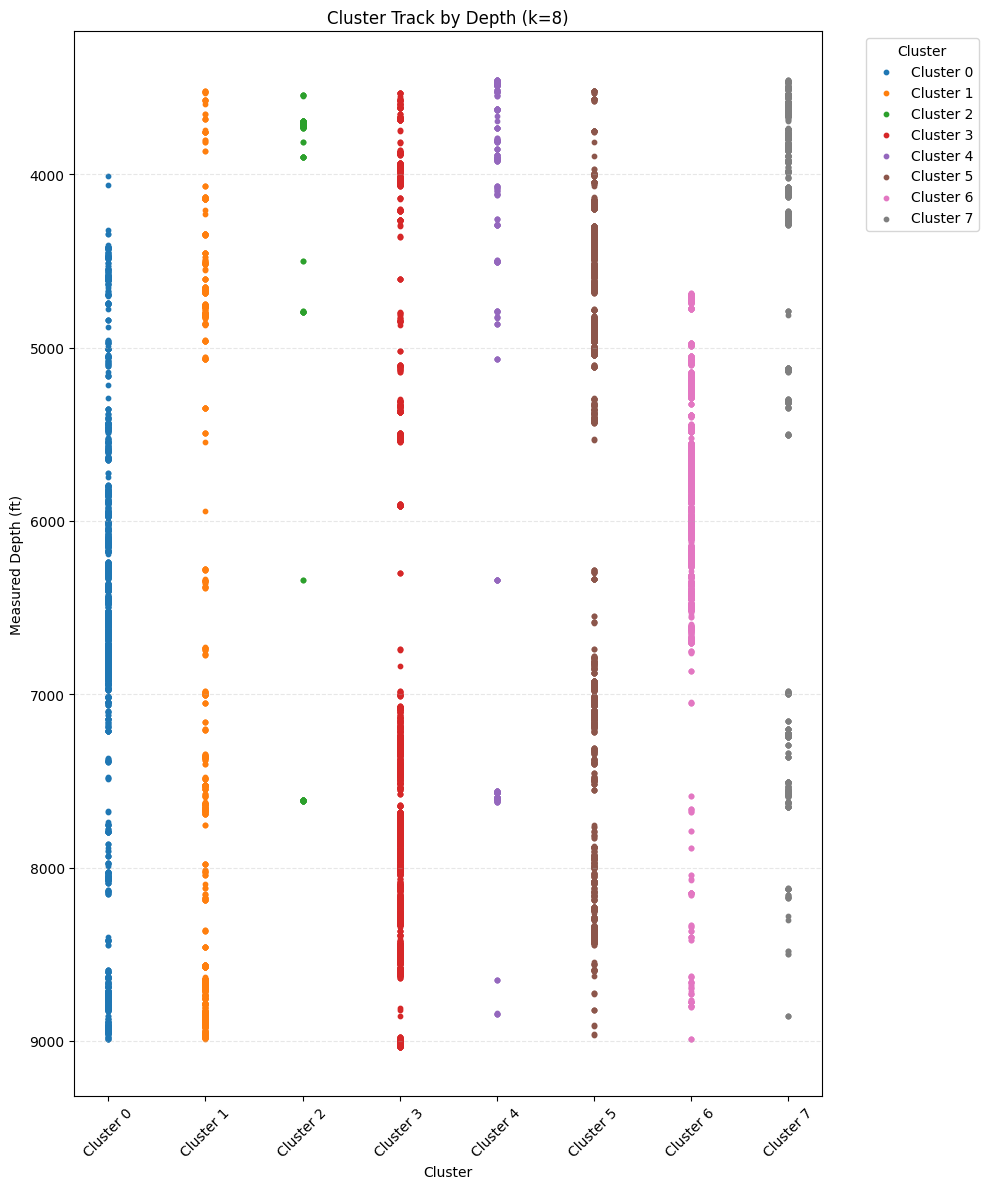

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure clusters are numeric and clean
df_kmeans_3['Cluster'] = df_kmeans_3['Cluster'].astype(int)

# Unique clusters (sorted)
cluster_order = sorted(df_kmeans_3['Cluster'].unique())

# Set up figure
plt.figure(figsize=(10, 12))

# Assign color palette automatically
palette = sns.color_palette("tab10", n_colors=len(cluster_order))

# Plot each cluster as a vertical column
for i, cluster in enumerate(cluster_order):
    subset = df_kmeans_3[df_kmeans_3['Cluster'] == cluster]
    plt.scatter(
        x=[i] * len(subset),
        y=subset['MD'],
        color=palette[i],
        s=10,
        label=f"Cluster {cluster}"
    )

# Format axis and labels
plt.gca().invert_yaxis()
plt.xticks(range(len(cluster_order)), [f"Cluster {i}" for i in cluster_order], rotation=45)
plt.xlabel("Cluster")
plt.ylabel("Measured Depth (ft)")
plt.title("Cluster Track by Depth (k=8)")
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


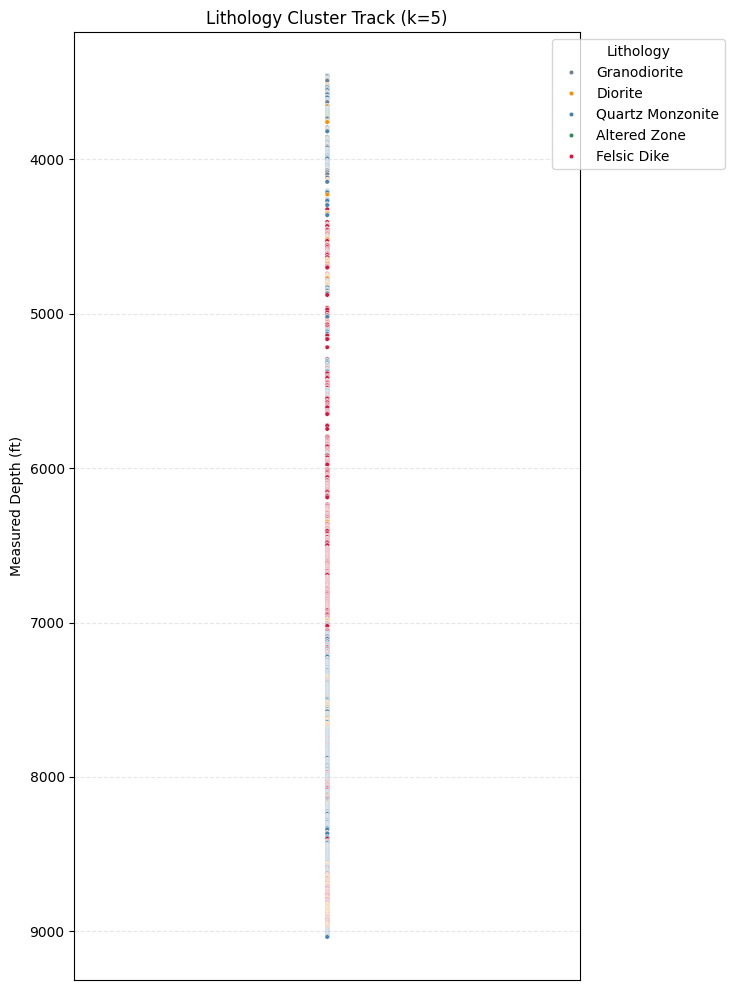

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define cluster-to-lithology mapping
cluster_to_litho = {
    0: 'Felsic Dike',
    1: 'Diorite',
    2: 'Altered Zone',
    3: 'Quartz Monzonite',
    4: 'Granodiorite'
}

# Map to new column
df_kmeans_3['Lithology_Label'] = df_kmeans_3['Cluster'].map(cluster_to_litho)

# Set color palette for visual distinction
litho_palette = {
    'Felsic Dike': 'crimson',
    'Diorite': 'darkorange',
    'Altered Zone': 'seagreen',
    'Quartz Monzonite': 'steelblue',
    'Granodiorite': 'slategray'
}

# Create log-style vertical lithology plot
plt.figure(figsize=(6, 10))

sns.scatterplot(
    y=df_kmeans_3['MD'],
    x=['Lithology'] * len(df_kmeans_3),  # Single vertical strip
    hue=df_kmeans_3['Lithology_Label'],
    palette=litho_palette,
    s=10,
    legend=True
)

plt.gca().invert_yaxis()
plt.title("Lithology Cluster Track (k=5)")
plt.xlabel("")
plt.ylabel("Measured Depth (ft)")
plt.xticks([])
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Lithology', loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()


KeyError: np.int32(5)

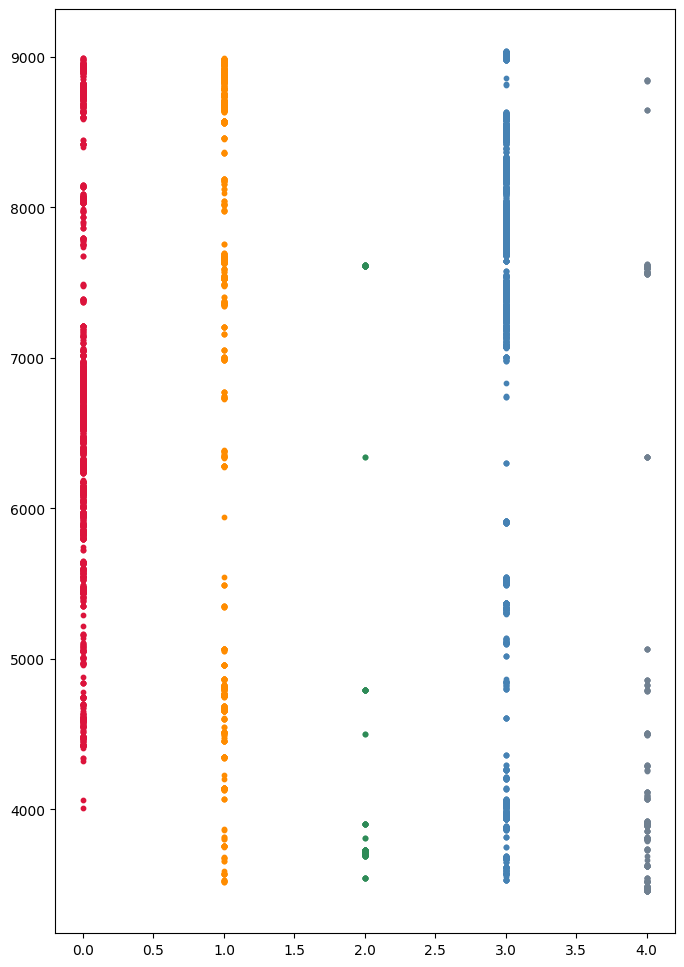

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lithology labels and color palette
cluster_to_litho = {
    0: 'Felsic Dike',
    1: 'Diorite',
    2: 'Altered Zone',
    3: 'Quartz Monzonite',
    4: 'Granodiorite'
}
df_kmeans_3['Lithology_Label'] = df_kmeans_3['Cluster'].map(cluster_to_litho)

litho_palette = {
    'Felsic Dike': 'crimson',
    'Diorite': 'darkorange',
    'Altered Zone': 'seagreen',
    'Quartz Monzonite': 'steelblue',
    'Granodiorite': 'slategray'
}

# Plot setup
plt.figure(figsize=(8, 12))
cluster_order = sorted(df_kmeans_3['Cluster'].unique())

# Loop through clusters and plot side-by-side
for i, cluster in enumerate(cluster_order):
    subset = df_kmeans_3[df_kmeans_3['Cluster'] == cluster]
    plt.scatter(
        x=[i] * len(subset),
        y=subset['MD'],
        color=litho_palette[cluster_to_litho[cluster]],
        s=10,
        label=cluster_to_litho[cluster]
    )

# Format the plot
plt.gca().invert_yaxis()
plt.xticks(range(len(cluster_order)), [cluster_to_litho[c] for c in cluster_order], rotation=45, ha='right')
plt.xlabel("Lithology")
plt.ylabel("Measured Depth (ft)")
plt.title("Separated Lithology Columns by Cluster")
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


I compare the result with actual formation log: they doesn't match. Actual log mostly contains Granodiorite and other few lithologies. I am not disappointed, this task misdirected me I guess. I dpn't give me any help to proceed 